<a href="https://colab.research.google.com/github/sulucay01/multimodal-rs-segmentation/blob/dev/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Data Exploration

DI725 Term Project — Multimodal Fusion for Remote Sensing Land Cover Segmentation.

Exploratory analysis of the dataset before model training.

**Dataset:** 10,000 remote sensing images, 7 land cover classes (Tree, Shrub, Grass, Crop, Built-up, Barren, Water), 5 caption variants per image.

Sections:
1. Setup
2. File matching
3. Sample visualization
4. Class distribution
5. Caption accuracy
6. Vision-only caption example

## 1. Setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Project paths
from pathlib import Path

PROJECT_DIR  = Path('/content/drive/MyDrive/DI725_Project')
DATA_DIR     = PROJECT_DIR / 'data'
IMAGES_DIR   = DATA_DIR / 'images'
MASKS_DIR    = DATA_DIR / 'masks'
CAPTIONS_CSV = DATA_DIR / 'captions.csv'

assert DATA_DIR.exists(), f'Data dir not found: {DATA_DIR}'

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# Class definitions from the project file
CLASS_NAMES = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']

CLASS_RGB = {
    'Tree':     (0,   100, 0),
    'Shrub':    (255, 182, 193),
    'Grass':    (154, 205, 50),
    'Crop':     (255, 215, 0),
    'Built-up': (139, 69,  19),
    'Barren':   (211, 211, 211),
    'Water':    (0,   0,   255),
}

# Per class colors for bar charts (RGB ints in [0,255] → floats in [0,1])
class_colors = {c: np.array(rgb) / 255.0 for c, rgb in CLASS_RGB.items()}

In [ ]:
# Caption columns and class-percentage columns from the CSV.
CAPTION_COLS = [
    'hybrid_gemma3-4b',
    'hybrid_qwen3-vl-8b',
    'text_qwen3-4b',
    'vision_gemma3-4b',
    'vision_qwen3-vl-8b',
]
CAPTION_SHORT = ['Hyb-G', 'Hyb-Q', 'Txt-Q', 'Vis-G', 'Vis-Q']  # for compact tables

df = pd.read_csv(CAPTIONS_CSV)
print(f'Rows: {len(df)}, columns: {len(df.columns)}')

Rows: 10000, columns: 14


## 2. File matching

Confirm that every image has a corresponding mask and caption row.

In [ ]:
# Filename matching across the three sources
csv_filenames   = set(df['filename'].values)
image_filenames = set(p.name for p in IMAGES_DIR.glob('*.png'))
mask_filenames  = set(p.name for p in MASKS_DIR.glob('*.png'))

print(f'Files in CSV   : {len(csv_filenames)}')
print(f'Files in images: {len(image_filenames)}')
print(f'Files in masks : {len(mask_filenames)}')

missing_images = csv_filenames - image_filenames
missing_masks  = csv_filenames - mask_filenames
duplicates     = df['filename'].duplicated().sum()

print(f'\nCSV rows missing an image: {len(missing_images)}')
print(f'CSV rows missing a mask  : {len(missing_masks)}')
print(f'Duplicate filenames in CSV: {duplicates}')

Files in CSV   : 10000
Files in images: 10000
Files in masks : 10000

CSV rows missing an image: 0
CSV rows missing a mask  : 0
Duplicate filenames in CSV: 0


## 3. Sample visualization

One sample shown as image and RGB mask.

In [ ]:
# Load one sample
sample_name = df.iloc[0]['filename']
img  = np.array(Image.open(IMAGES_DIR / sample_name))
mask = np.array(Image.open(MASKS_DIR  / sample_name))

print(f'Filename: {sample_name}')
print(f'Image shape: {img.shape}, dtype: {img.dtype}')
print(f'Mask  shape: {mask.shape}, dtype: {mask.dtype}')

Filename: 0073.png
Image shape: (256, 256, 3), dtype: uint8
Mask  shape: (256, 256, 3), dtype: uint8


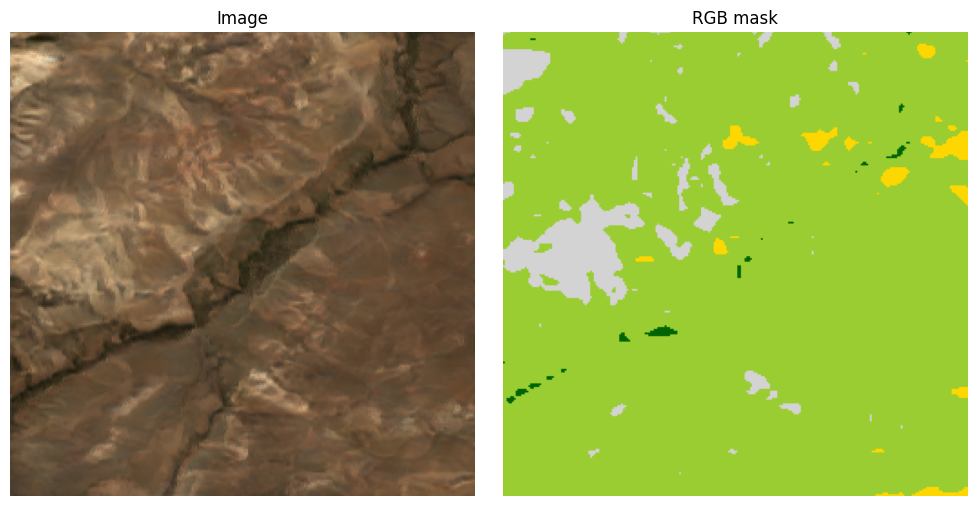

In [ ]:
# Image and RGB mask side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img);  axes[0].set_title('Image');    axes[0].axis('off')
axes[1].imshow(mask); axes[1].set_title('RGB mask'); axes[1].axis('off')
plt.tight_layout()
plt.show()

## 4. Class distribution

- Coverage: average pixel percentage per image
- Presence: fraction of images containing the class

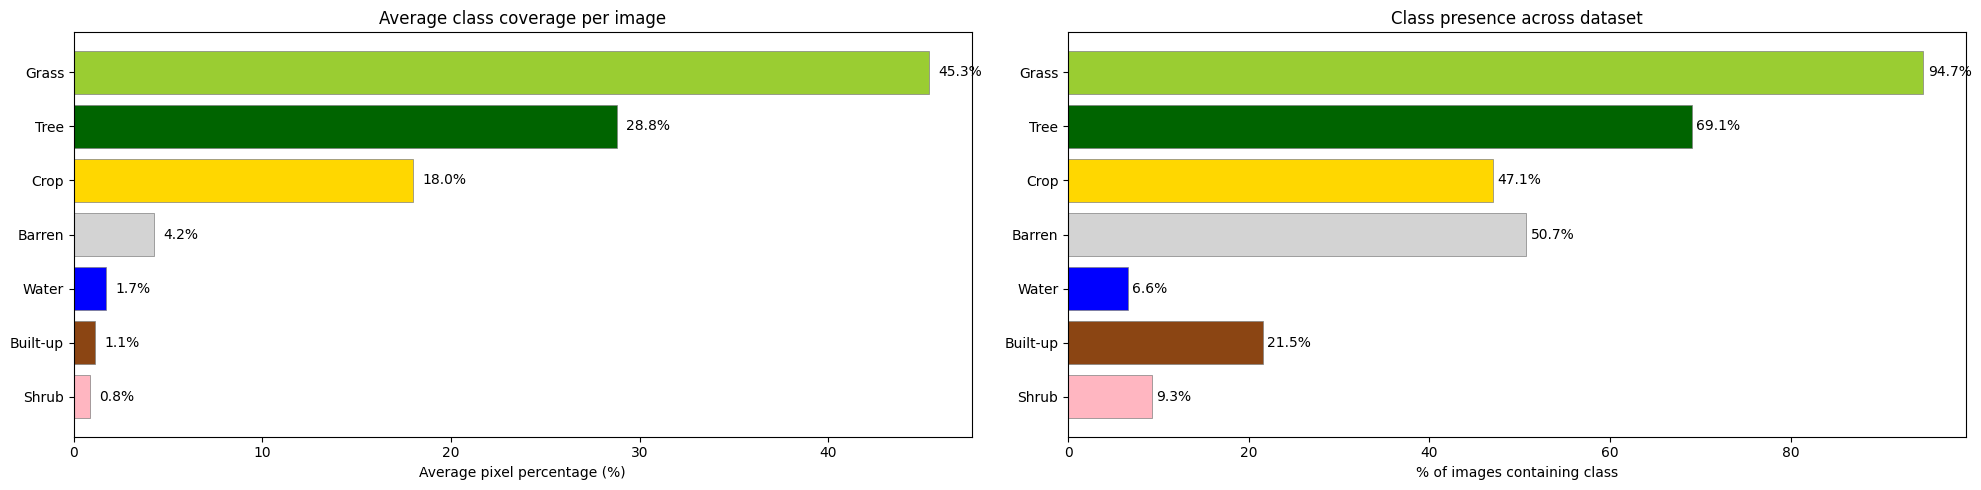

In [ ]:
# Coverage = pixel-weighted, Presence = image-weighted
avg_pct  = df[CLASS_NAMES].mean().sort_values(ascending=False)
presence = (df[CLASS_NAMES] > 0).mean().reindex(avg_pct.index) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
bar_colors = [class_colors[c] for c in avg_pct.index]

axes[0].barh(avg_pct.index, avg_pct.values, color=bar_colors, edgecolor='gray', linewidth=0.5)
axes[0].set_xlabel('Average pixel percentage (%)')
axes[0].set_title('Average class coverage per image')
axes[0].invert_yaxis()
for i, v in enumerate(avg_pct.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

axes[1].barh(avg_pct.index, presence.values, color=bar_colors, edgecolor='gray', linewidth=0.5)
axes[1].set_xlabel('% of images containing class')
axes[1].set_title('Class presence across dataset')
axes[1].invert_yaxis()
for i, v in enumerate(presence.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Observations**

- Grass, Tree, Crop dominate by both views, common and large when present.
- Barren appears in 50.7% of images but covers only 4.2% of pixels overall — a frequent secondary class, rarely the focus.
- Built-up shows the same pattern more sharply. Present in 21.5% of images, only 1.1% of pixels.
- Water and Shrub are rare on both axes. Uncommon to see at all, and small when they appear.

The strongest finding is the gap between presence and coverage for Barren and Built-up: classes that show up often but never as the dominant element.

## 5. Caption accuracy

For each class, find images where it is substantially present and check whether each caption variant mentions it. The miss rate is the fraction of those images whose caption fails to mention the class.

Threshold is **>60%** for classes that can dominate, and **>5%** for Shrub, which never reaches the 60% bar.

In [ ]:
# Synonyms used to detect whether captions mention the class
SYNONYMS = {
    'Tree':     ['tree', 'forest', 'woodland', 'wooded'],
    'Shrub':    ['shrub', 'scrub', 'bush', 'brush'],
    'Grass':    ['grass', 'grassland', 'pasture', 'meadow'],
    'Crop':     ['crop', 'cultivat', 'agricult', 'farmland', 'field'],
    'Built-up': ['built', 'building', 'urban', 'settlement', 'structure'],
    'Barren':   ['barren', 'bare', 'exposed', 'rock', 'soil'],
    'Water':    ['water', 'river', 'lake', 'pond', 'stream', 'ocean'],
}

# Per-class threshold: >60% for classes that commonly dominate,
# >5% for Shrub, which never reaches dominance.
THRESHOLDS = {c: 60 for c in SYNONYMS}
THRESHOLDS['Shrub'] = 5

print('Caption miss rate (% of substantially-present-class images NOT mentioning the class)\n')
COL_W = 18

# Header
print(f"{'Class':<10} {'Thresh':>7} {'#Imgs':>6}  ", end='')
for label in CAPTION_SHORT:
    print(f'{label:>{COL_W}}', end='')
print()
print('-' * (10 + 7 + 6 + 2 + COL_W * len(CAPTION_SHORT)))

# Body
for cls, words in SYNONYMS.items():
    thresh = THRESHOLDS[cls]
    subset = df[df[cls] > thresh]
    # skip classes with too few examples for a meaningful rate
    if len(subset) < 10:
        continue

    print(f'{cls:<10} {f">{thresh}%":>7} {len(subset):>6}  ', end='')
    pattern = '|'.join(words)
    for col in CAPTION_COLS:
        mentions  = subset[col].astype(str).str.lower().str.contains(pattern).sum()
        miss_rate = (1 - mentions / len(subset)) * 100
        marker    = '*' if miss_rate > 50 else ' '
        print(f'{miss_rate:>{COL_W - 2}.1f}%{marker}', end='')
    print()

print('\n* indicates miss rate > 50%')

Caption miss rate (% of substantially-present-class images NOT mentioning the class)

Class       Thresh  #Imgs               Hyb-G             Hyb-Q             Txt-Q             Vis-G             Vis-Q
-------------------------------------------------------------------------------------------------------------------
Tree          >60%   2424               0.0%              0.0%              0.0%              6.3%              5.3% 
Shrub          >5%    444               2.9%              1.8%             31.8%             98.2%*            99.5%*
Grass         >60%   3806               0.0%              0.1%              0.0%             94.8%*            99.1%*
Crop          >60%   1434               0.0%              0.0%              0.0%             15.3%             15.9% 
Built-up      >60%     25               0.0%              0.0%              0.0%             12.0%              0.0% 
Barren        >60%    134               0.0%              0.0%              0.0%          

**Observations**
- Hybrid captions are reliable across all classes (≤3% miss).
- Text-only captions are perfect on dominant classes but miss Shrub 31.8% of the time, even with access to class percentages.
- Vision-only captions fail almost completely on Grass (>94%) and Shrub (>98%), and show elevated miss rates for Crop, Barren, and Water.
- Tree is the only class captioned reliably across every variant.

The source-dependent gap, especially for Grass and Shrub, motivates the **caption-variant ablation study** in subsequent experiments.

## 6. Vision-only caption example

A concrete example illustrating the failure mode quantified above.

In [ ]:
# Image where vision-only captions misread the scene
ex = df[df['filename'] == '0073.png'].iloc[0]

print(f"Image: {ex['filename']}")
print(f"Ground truth: Grass={ex['Grass']}%, Crop={ex['Crop']}%, Barren={ex['Barren']}%")
print('=' * 60)

for col in CAPTION_COLS:
    print(f'\n[{col}]')
    print(f'  {ex[col][:200]}')

Image: 0073.png
Ground truth: Grass=92%, Crop=2%, Barren=6%

[hybrid_gemma3-4b]
  The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the te

[hybrid_qwen3-vl-8b]
  The scene is dominated by grassland covering 92% of the area, with sparse, fragmented crop patches and small barren zones, suggesting a largely natural, lightly managed landscape with minor agricultur

[text_qwen3-4b]
  The scene is predominantly covered by grass, indicating a large area of natural or managed pastureland. Crop coverage is minimal, suggesting limited agricultural activity in the region.

[vision_gemma3-4b]
  This image depicts a rugged, arid landscape characterized by extensive rocky terrain and deeply incised gullies, likely indicative of a desert or semi-arid environment with minimal vegetation cover. T

[vision_qwen3-vl-8b]
  This remote sensing image shows a rugged

**Observation**

Hybrid and text-only captions identify the dominant classes correctly, but vision-only captions describe a different scene.

## Summary

- 10,000 aligned image / mask / caption rows. No missing or duplicated entries.
- Coverage and presence orderings disagree, most notably for Barren (50.7% presence, 4.2% coverage) and Built-up (21.5% presence, 1.1% coverage).
- Caption accuracy varies by source: hybrid and text-only are reliable on dominant classes (text-only misses Shrub 31.8% of the time), while vision-only fails on Grass and Shrub (>94%). Motivates the caption-variant ablation study.

GitHub Repository:
https://github.com/sulucay01/multimodal-rs-segmentation/tree/main

Weights & Biases Project:
https://wandb.ai/selingoktas98-metu-middle-east-technical-university/di725_project?nw=nwuserselingoktas98